# Data Analysis of Titanic Passengers

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

print(pd.__version__)

3.0.0


Reload the data converting into pandas.DataFrame.

In [2]:
titanic = pd.read_csv("data/Titanic.csv")

- Affichez les informations sur le `DataFrame` comme le type et le nom des colonnes, le nombre de lignes, si certaines colonnes contiennent des `nan`...

In [3]:
display(titanic)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


Les colonnes sont :
- `PassengerId` : Identifiant du passager
- `Survived` : True (1) / False (0)
- `Pclass` : Classe du ticket : 1, 2 ou 3.
- `Name` : Nom du passager
- `Sex` : Genre du passager (male/female)
- `Age` : Age en années
- `Cabin` : Numéro de cabine
- `Embarked` : Port d’embarquement ( C : Cherbourg; Q Queenstown; S Southampton)

On va commencer par observer nos données, en répondant à des questions descriptives :
1. Quel sexe a le plus de chances de survie ?
2. Est-ce que les enfants ont eu plus de chances de survie ?
3. Quelle est la proportion de survie selon le port d'embarquement ?

## Quel sexe a le plus de chance de survie ?

- Fabriquer une table de synthèse à l'aide de la commande `groupby` en regroupant les passagers selon leur sexe puis selon s'ils ont survécu ou pas.
- Proposer une représentation graphique type camembert pour représenter la répartition de la survie selon le sexe. 
- Calculer le pourcentage de survie pour les femmes et pour les hommes.


In [7]:
survival_by_sex = titanic.groupby(["Sex", "Survived"]).count()

number = len(titanic)
survival_by_sex_percentage = survival_by_sex / number * 100

display(survival_by_sex_percentage.style.format("{:.2f}%"))

In [8]:
Sex = survival_by_sex_percentage["PassengerId"]

display(Sex.apply(lambda x: f"{x:.2f}%"))

Sex     Survived
female  0            9.09%
        1           26.15%
male    0           52.53%
        1           12.23%
Name: PassengerId, dtype: str

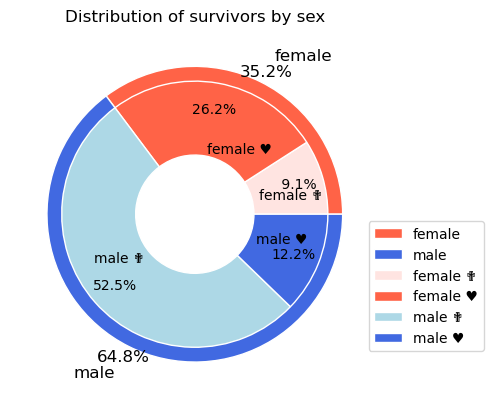

In [9]:
fig, ax = plt.subplots(1, 1)

outer = Sex.groupby(level = 0).sum()
inner = Sex
outer_colors = ["tomato", "royalblue"]
inner_colors = ["mistyrose", "tomato", "lightblue", "royalblue"]
outer_labels = ["female", "male"]
inner_labels = ["female ✟", "female ♥", "male ✟", "male ♥"]


ax.pie(
    outer,
    colors = outer_colors,
    radius = 1,
    labels = outer_labels,
    labeldistance = 1.2,
    autopct = ("%4.1f%%"), # place the numbers
    pctdistance = 1.08,
    wedgeprops = dict(width = 0.5, edgecolor = "white"), # width -> central empty circle
    textprops = dict(fontsize = 12)
)

ax.pie(
    inner,
    colors = inner_colors,
    radius = 0.9,
    labels = inner_labels,
    labeldistance = 0.5,
    autopct = ("%4.1f%%"),
    pctdistance = 0.8,
    wedgeprops = dict(width = 0.5, edgecolor = "white"),
    textprops = dict(fontsize = 10),
)
ax.legend(bbox_to_anchor = (1.3, 0.5))
ax.set_title("Distribution of survivors by sex")
plt.show()

## Et les enfants ?

- Créez un nouveau `DataFrame` en filtrant les passagers dont on ne connait pas l'âge.
- Calculez le pourcentage de survie pour les enfants (sans différenciation du sexe).

In [10]:
titanic_age = titanic[titanic["Age"].notna()]
display(titanic_age)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
children = titanic_age[titanic_age["Age"] < 18]
Age = children.groupby(["Survived"]).count() / len(children) * 100
display(Age["PassengerId"].apply(lambda x : f"{x:.2f}%"))

print()
survival_rate_children = len(children[children["Survived"] == 1]) / len(children) * 100
print(f"The survival rate of the children is {survival_rate_children:.2f}%")

Survived
0    46.02%
1    53.98%
Name: PassengerId, dtype: str


The survival rate of the children is 53.98%


## Recherche d'une corrélation avec le port d'embarquement

Nous pouvons nous demander si les chances de survie dépendent du port d'embarquement. Un problème est que ce port n'est pas renseigné pour certains passagers. 

- Affichez tous les ports d'embarquement possibles
- Comptez et affichez le nombre de passagers ayant embarqué dans chacun des ports ou n'ayant pas cette information.

In [12]:
Embarked = titanic.groupby(["Embarked"]).count()
Nan_Embarked = titanic[titanic["Embarked"].isna()]
display(Embarked["PassengerId"])
display(Nan_Embarked)
print(f"The number of people who doesn't have information about embarked is {len(Nan_Embarked)}")

Embarked
C    168
Q     77
S    644
Name: PassengerId, dtype: int64

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


The number of people who doesn't have information about embarked is 2


- Trouvez le nom des deux passagères dont le nom du port d'embarquement n'est pas donné.
- Complétez l'information manquante dans le `DataFrame` afin que tous les passagers aient un port d'embarquement.

On peut retrouver la trace de ces deux personnes sur internet 
- https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html
- https://www.encyclopedia-titanica.org/titanic-survivor/amelia-icard.html

et il est indiqué qu'elles sont montées à Southampton.

In [13]:
Nan_Embarked = titanic[titanic["Embarked"].isna()]
display(Nan_Embarked["Name"])

titanic.at[61, "Embarked"] = "S"
titanic.at[829, "Embarked"] = "S"

display(len(titanic[titanic["Embarked"].isna()]) == 0)

61                           Icard, Miss. Amelie
829    Stone, Mrs. George Nelson (Martha Evelyn)
Name: Name, dtype: str

True

Calculez la proportion de survie selon le port d'embarquement. Essayez d'obtenir un graphique ressemblant à celui-ci.

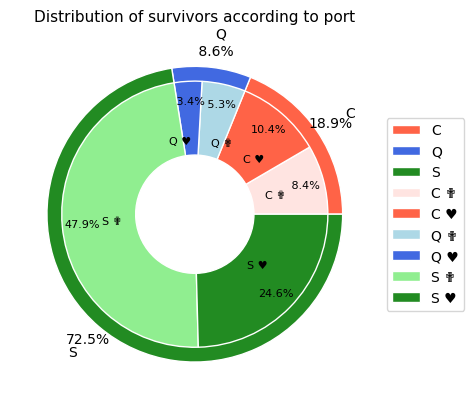

In [14]:
fig, ax = plt.subplots(1, 1)

Port = titanic.groupby(["Embarked","Survived"])["PassengerId"].count() / len(titanic) * 100

outer = Port.groupby(level = 0).sum()
inner = Port
outer_colors = ["tomato", "royalblue", "forestgreen"]
inner_colors = ["mistyrose", "tomato", "lightblue", "royalblue", "lightgreen", "forestgreen"]
outer_labels = ["C", "Q", "S"]
inner_labels = ["C ✟", "C ♥", "Q ✟", "Q ♥", "S ✟", "S ♥"]


ax.pie(
    outer,
    colors = outer_colors,
    radius = 1,
    labels = outer_labels,
    labeldistance = 1.23,
    autopct = ("%4.1f%%"), # place the numbers
    pctdistance = 1.11,
    wedgeprops = dict(width = 0.5, edgecolor = "white"), # width -> central empty circle
    textprops = dict(fontsize = 10)
)

#inner.plot(ax=..., kind = 'pie')
ax.pie(
    inner,
    colors = inner_colors,
    radius = 0.9,
    labels = inner_labels,
    labeldistance = 0.55,
    autopct = ("%4.1f%%"),
    pctdistance = 0.85,
    wedgeprops = dict(width = 0.5, edgecolor = "white"),
    textprops = dict(fontsize = 8),
)
ax.legend(loc = 'center left',bbox_to_anchor = (1, .5))
ax.set_title("Distribution of survivors according to port", fontsize = 11)
plt.show()

## Et une corrélation avec la classe de la cabine ?

Proposez un graphique type camembert pour les survivants/morts selon les trois classes de la cabine occupée. Essayez d'obtenir un graphique ressemblant à celui-ci.

In [15]:
if(len(titanic[titanic["Pclass"].isna()]) != 0):
    raise ValueError("Pclass has empty datas")

Cabine = titanic.groupby(["Pclass", "Survived"]).count()["PassengerId"]
display(Cabine)

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: PassengerId, dtype: int64

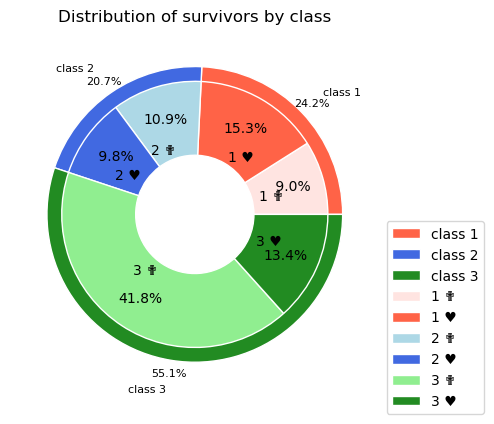

In [16]:
fig, ax = plt.subplots(1, 1)

outer = Cabine.groupby(level = 0).sum()
inner = Cabine
outer_colors = ["tomato", "royalblue", "forestgreen"]
inner_colors = ["mistyrose", "tomato", "lightblue", "royalblue", "lightgreen", "forestgreen"]
outer_labels = ["class 1", "class 2", "class 3"]
inner_labels = ["1 ✟", "1 ♥", "2 ✟", "2 ♥", "3 ✟", "3 ♥"]

ax.pie(
    outer,
    colors = outer_colors,
    labels = outer_labels,
    labeldistance = 1.2,
    wedgeprops = dict(width = 0.5, edgecolor = "white"),
    autopct = ("%4.1f%%"),
    pctdistance = 1.09,
    textprops = {"fontsize" : 8}
)

ax.pie(
    inner,
    colors = inner_colors,
    labels = inner_labels,
    labeldistance = 0.5,
    radius = 0.9,
    wedgeprops = dict(width = 0.5, edgecolor = "white"),
    autopct = "%4.1f%%",
    pctdistance = 0.75,
)

ax.legend(bbox_to_anchor = (1, 0.5))
ax.set_title("Distribution of survivors by class")
plt.show()